In [1]:
#%matplotlib ipympl

import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json
import numpy as np

In [109]:
def triangular(x, a, b, c):
    # a < b < c (can be tensors or scalars, broadcastable with x)
    left  = (x - a) / (b - a)
    right = (c - x) / (c - b)
    return torch.clamp(torch.minimum(left, right), min=0.0, max=1.0)

def ramp_right(x, a, b):
    y = (x - a) / (b - a)
    return torch.clamp(y, min=0.0, max=1.0)

def ramp_left(x, a, b):
    y = - (x - b) / (b - a)
    return torch.clamp(y, min=0.0, max=1.0)

def hypo_glucose(x):
    return ramp_left(x,90/18,105/18) # 70 - 105 mg/dl

def target_glucose(x):
    return triangular(x,90/18,105/18,180/18) # 70 - 180 mg/dl

def hyper_glucose(x):
    return ramp_right(x, 150/18, 300/18) # 105 - 180 mg/dl

def zero_dose(x):
    return ramp_left(x,0,0.01) # mU/kg

def low_dose(x):
    return triangular(x, 0.0, 0.01, 0.1) # mU/kg

def high_dose(x):
    return ramp_right(x, 0.05, 0.2) # mU/kg

def bolus_dose(x):
    return ramp_right(x, 0.1, 1.5) # mU/kg

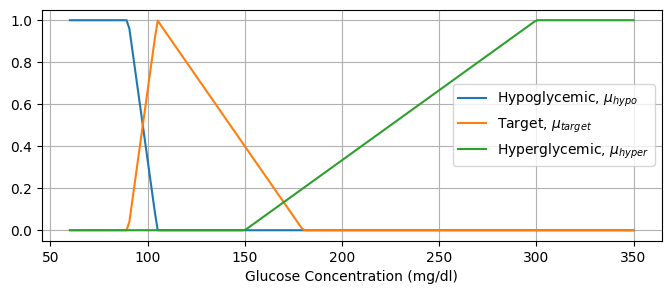

In [142]:
x = torch.linspace(60, 350, 200)/18

y1 = hypo_glucose(x)
y2 = target_glucose(x)
y3 = hyper_glucose(x)
F = plt.figure(figsize=(8,3))
ax = F.add_subplot()
ax.plot(x*18,y1,x*18,y2,x*18,y3)
ax.grid(which='both')
ax.set_xlabel('Glucose Concentration (mg/dl)')
ax.legend(['Hypoglycemic, $\mu_{hypo}$','Target, $\mu_{target}$','Hyperglycemic, $\mu_{hyper}$'])
plt.show(F)
F.savefig('glucose_mf.pdf',dpi=300,pad_inches=0,bbox_inches='tight')

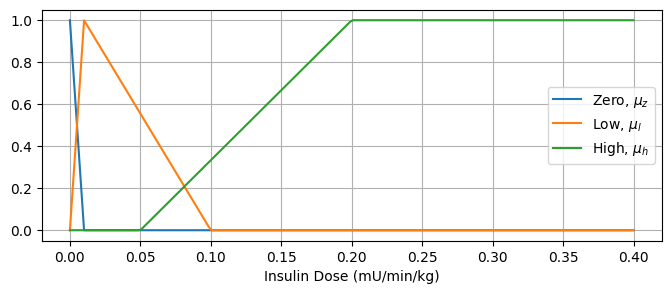

In [143]:
x = torch.linspace(0, 0.4, 200)

y1 = zero_dose(x)
y2 = low_dose(x)
y3 = high_dose(x)
F = plt.figure(figsize=(8,3))
ax = F.add_subplot()
ax.plot(x,y1,x,y2,x,y3)
ax.grid(which='both')
ax.set_xlabel('Insulin Dose (mU/min/kg)')
ax.legend(['Zero, $\mu_{z}$','Low, $\mu_{l}$','High, $\mu_{h}$'])
plt.show(F)
F.savefig('insulin_mf.pdf',dpi=300,pad_inches=0,bbox_inches='tight')

In [2]:
f = open("sim_result_1.json")
dat1 = json.loads(f.read())
f.close()
f = open("sim_result_3day_fz.json")
dat2 = json.loads(f.read())
f.close()
time = np.arange(0,len(dat1['u']))
F = plt.plot(time,np.array(dat2['y'])*18,'b',time,np.array(dat1['y'])*18,'r')
plt.show(F)

FileNotFoundError: [Errno 2] No such file or directory: 'sim_result_3day_fz.json'

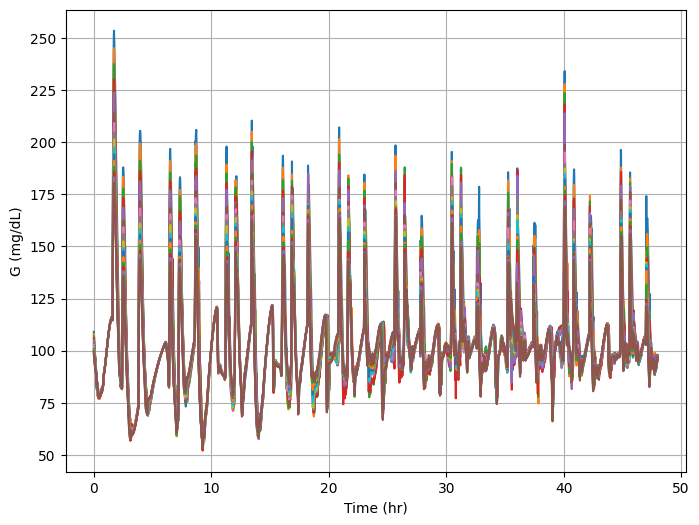

In [18]:
f = open("training_10_day.json")
dat1 = json.loads(f.read())
f.close()
time = np.arange(0,len(dat1['u']))
F = plt.figure(figsize=(8,6))
ax = F.add_subplot()
ax.plot(time/60.0,np.array(dat1['y'])*18)
ax.grid(which='both')
ax.set_xlabel('Time (hr)')
ax.set_ylabel('G (mg/dL)')
plt.show(F)
F.savefig('glucose_training.pdf',dpi=300,pad_inches=0,bbox_inches='tight')

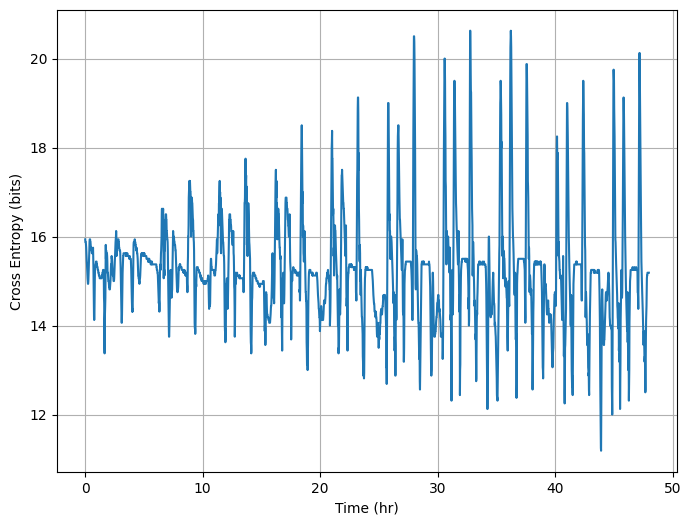

In [19]:
F = plt.figure(figsize=(8,6))
ax = F.add_subplot()
ax.plot(time/60.0,np.array(dat1['loss_ce']))
ax.grid(which='both')
ax.set_xlabel('Time (hr)')
ax.set_ylabel('Cross Entropy (bits)')
plt.show(F)
F.savefig('loss_ce_training.pdf',dpi=300,pad_inches=0,bbox_inches='tight')

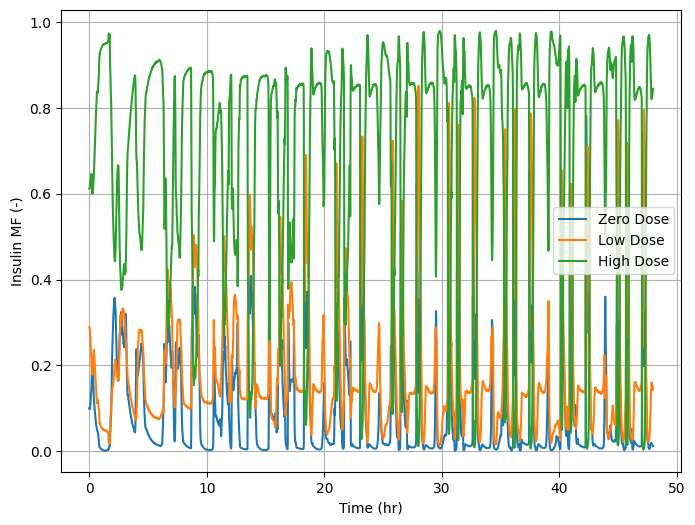

In [22]:
F = plt.figure(figsize=(8,6))
ax = F.add_subplot()
z = np.array(dat1['zero_dose_p'])
l = np.array(dat1['low_dose_p'])
h = np.array(dat1['high_dose_p'])
z1 = np.exp(-z)/(np.exp(-z)+np.exp(-l)+np.exp(-h))
l1 = np.exp(-l)/(np.exp(-z)+np.exp(-l)+np.exp(-h))
h1 = np.exp(-h)/(np.exp(-z)+np.exp(-l)+np.exp(-h))
ax.plot(time/60.0,z1,time/60.0,l1,time/60.0,h1)
ax.grid(which='both')
ax.set_xlabel('Time (hr)')
ax.set_ylabel('Insulin MF (-)')
ax.legend(['Zero Dose','Low Dose','High Dose'])
plt.show(F)
F.savefig('mf_training.pdf',dpi=300,pad_inches=0,bbox_inches='tight')

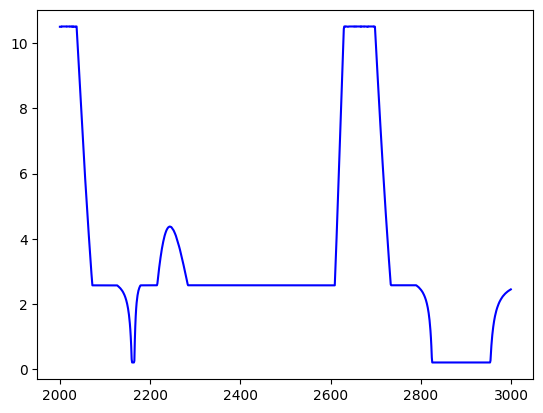

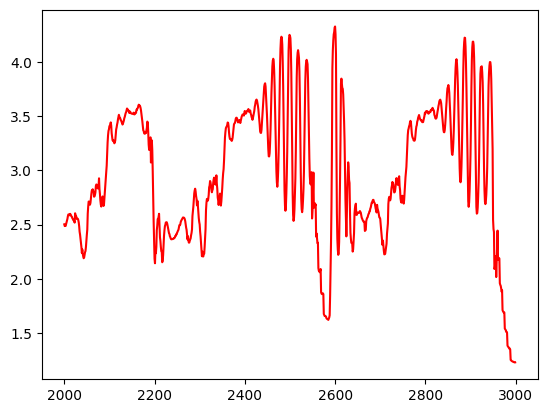

In [103]:
F = plt.plot(time[2000:3000],np.array(dat2['u'])[2000:3000,0],'b')
plt.show(F)
F = plt.plot(time[2000:3000],np.array(dat1['u'])[2000:3000,0],'r')
plt.show(F)

In [104]:
f = open("sim_result_1.json")
dat1 = json.loads(f.read())
f.close()
f = open("sim_result_10day_fz.json")
dat2 = json.loads(f.read())
f.close()

In [105]:
time = np.arange(0,len(dat['u']))
#time = time[0:24*60*1]

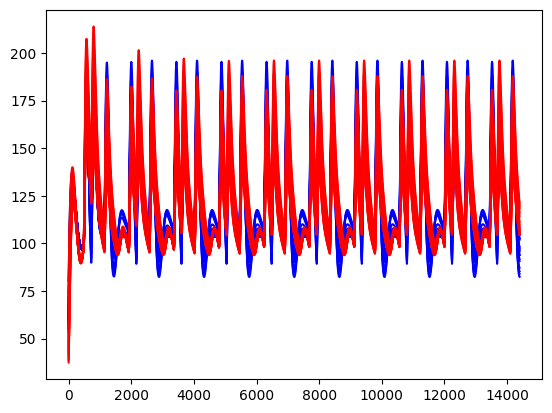

In [108]:
F = plt.plot(time,np.array(dat2['y'])*18,'b',time,np.array(dat1['y'])*18,'r')
plt.show(F)

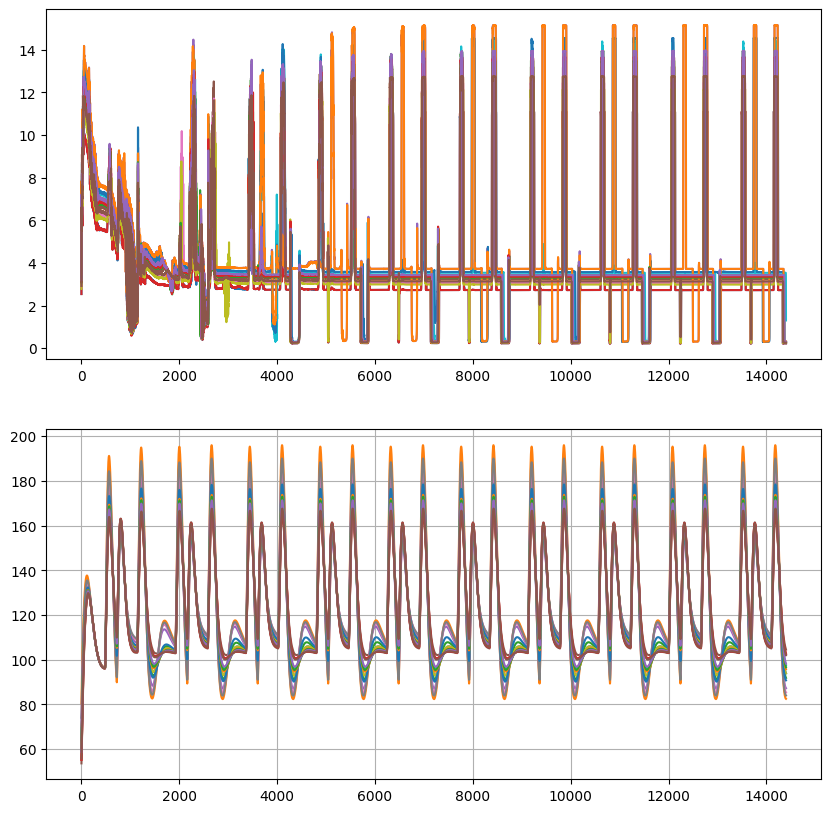

In [76]:
n1 = 0
n2 = 24*60*10
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(2,1,1)
ax1.plot(time[n1:n2],dat['u'][n1:n2])
ax2 = fig.add_subplot(2,1,2)
ax2.plot(time[n1:n2],np.array(dat2['y'][n1:n2])*18)
ax2.grid()
plt.show(fig)

In [69]:
f = open("sim_result_1.json")
dat = json.loads(f.read())
f.close()

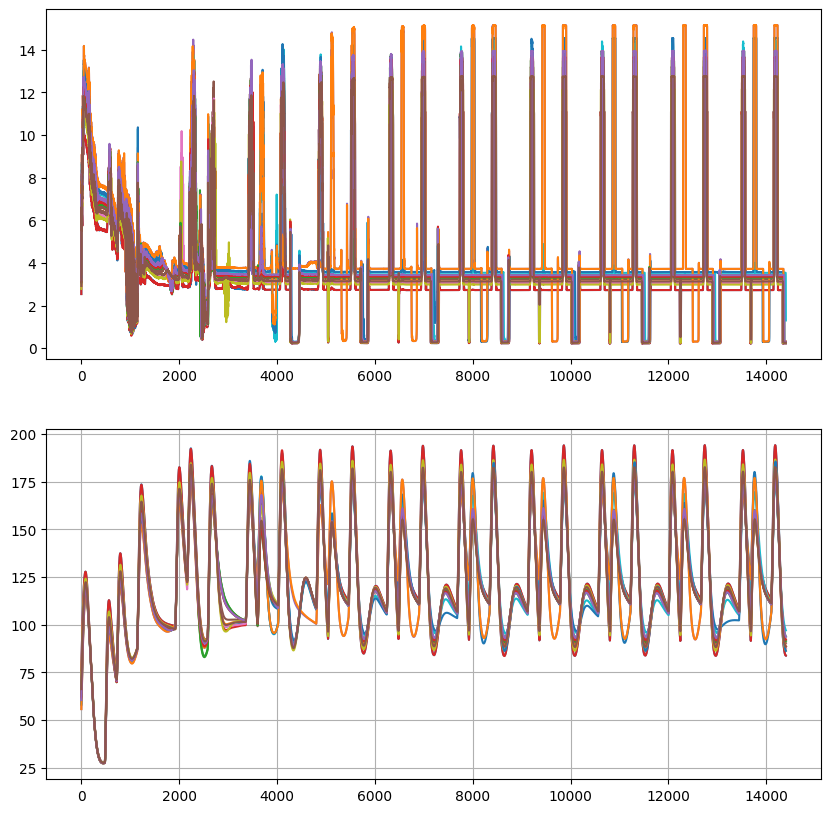

In [72]:
n1 = 0
n2 = 24*60*10
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(2,1,1)
ax1.plot(time[n1:n2],dat['u'][n1:n2])
ax2 = fig.add_subplot(2,1,2)
ax2.plot(time[n1:n2],np.array(dat['y'][n1:n2])*18)
ax2.grid()
plt.show(fig)

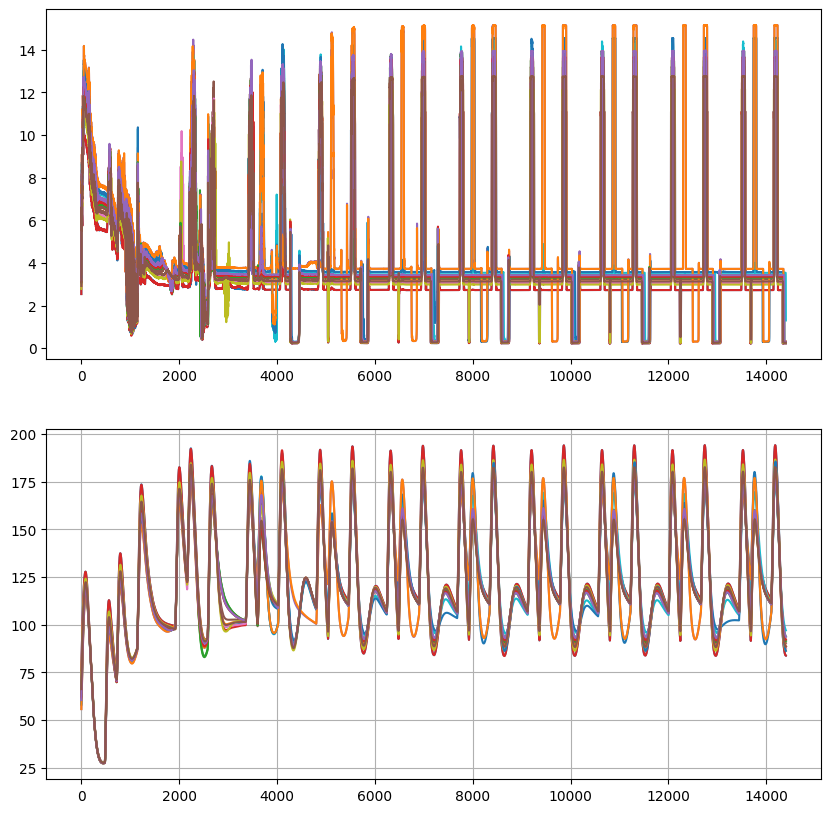

In [73]:
n1 = 0
n2 = 24*60*10
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(2,1,1)
ax1.plot(time[n1:n2],dat['u'][n1:n2])
ax2 = fig.add_subplot(2,1,2)
ax2.plot(time[n1:n2],np.array(dat['y'][n1:n2])*18)
ax2.grid()
plt.show(fig)

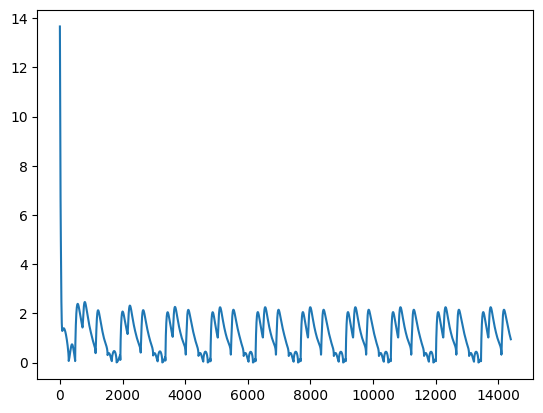

In [107]:
fig = plt.plot(time,dat1['loss'])
plt.show(fig)